In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
from sklearn.linear_model import LogisticRegression

In [2]:
from sklearn.inspection import DecisionBoundaryDisplay
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
# ======================================================================
# 1. LOAD AND PREPARE DATASETS
# ======================================================================

def load_datasets():
    """
    Load multiple open-source datasets for SVM demonstration
    """
    datasets_dict = {}

    # 1. Iris dataset (binary classification - setosa vs versicolor)
    print("Loading Iris dataset...")
    iris = datasets.load_iris()
    # Use only first two classes for binary classification
    X_iris = iris.data[iris.target != 2]
    y_iris = iris.target[iris.target != 2]
    datasets_dict['iris'] = {
        'X': X_iris, 'y': y_iris,
        'feature_names': iris.feature_names,
        'target_names': iris.target_names[:2],
        'description': 'Iris Setosa vs Versicolor (4 features)'
    }

    # 2. Breast Cancer dataset
    print("Loading Breast Cancer dataset...")
    cancer = datasets.load_breast_cancer()
    datasets_dict['cancer'] = {
        'X': cancer.data, 'y': cancer.target,
        'feature_names': cancer.feature_names,
        'target_names': cancer.target_names,
        'description': 'Breast Cancer Wisconsin (Diagnostic) Dataset'
    }

    # 3. Wine dataset (binary: class 0 vs class 1)
    print("Loading Wine dataset...")
    wine = datasets.load_wine()
    X_wine = wine.data[wine.target != 2]
    y_wine = wine.target[wine.target != 2]
    datasets_dict['wine'] = {
        'X': X_wine, 'y': y_wine,
        'feature_names': wine.feature_names,
        'target_names': wine.target_names[:2],
        'description': 'Wine Class 0 vs Class 1 (13 features)'
    }

    # 4. Make synthetic linearly separable data
    print("Creating synthetic datasets...")
    X_lin_sep, y_lin_sep = datasets.make_classification(
        n_samples=200, n_features=2, n_informative=2, n_redundant=0,
        n_clusters_per_class=1, flip_y=0, class_sep=2.0, random_state=42
    )
    datasets_dict['linear_separable'] = {
        'X': X_lin_sep, 'y': y_lin_sep,
        'feature_names': ['Feature 1', 'Feature 2'],
        'target_names': ['Class 0', 'Class 1'],
        'description': 'Synthetic Linearly Separable Data'
    }

    # 5. Make synthetic non-linearly separable data
    X_nonlin, y_nonlin = datasets.make_classification(
        n_samples=200, n_features=2, n_informative=2, n_redundant=0,
        n_clusters_per_class=1, flip_y=0.1, class_sep=1.0, random_state=42
    )
    # Add some noise to make it more challenging
    X_nonlin += np.random.normal(0, 0.3, X_nonlin.shape)
    datasets_dict['non_linear'] = {
        'X': X_nonlin, 'y': y_nonlin,
        'feature_names': ['Feature 1', 'Feature 2'],
        'target_names': ['Class 0', 'Class 1'],
        'description': 'Synthetic Non-linearly Separable Data'
    }

    return datasets_dict


In [4]:
# ======================================================================
# 2. HARD MARGIN SVM IMPLEMENTATION
# ======================================================================

class HardMarginSVM:
    """
    Implementation of Hard Margin Linear SVM
    Uses very large C to approximate hard margin
    """

    def __init__(self, C=1e10, random_state=42):
        """
        Initialize Hard Margin SVM

        Parameters:
        -----------
        C : float, default=1e10
            Very large C approximates hard margin
            (Hard margin requires C → ∞)
        random_state : int
            Random seed for reproducibility
        """
        self.C = C
        self.model = svm.SVC(
            kernel='linear',
            C=C,
            random_state=random_state,
            probability=False
        )
        self.is_fitted = False

    def fit(self, X, y):
        """Fit the hard margin SVM"""
        self.model.fit(X, y)
        self.is_fitted = True

        # Extract learned parameters
        self.w = self.model.coef_[0]
        self.b = self.model.intercept_[0]
        self.support_vectors = self.model.support_vectors_
        self.support_vector_indices = self.model.support_
        self.n_support_vectors = len(self.support_vectors)

        return self

    def predict(self, X):
        """Predict class labels"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.model.predict(X)

    def decision_function(self, X):
        """Return signed distance to hyperplane"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.model.decision_function(X)

    def get_margin(self):
        """Calculate the margin width"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        margin = 2.0 / np.linalg.norm(self.w)
        return margin

    def get_parameters(self):
        """Get all learned parameters"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")

        return {
            'weight_vector': self.w,
            'bias': self.b,
            'margin': self.get_margin(),
            'n_support_vectors': self.n_support_vectors,
            'support_vectors': self.support_vectors,
            'support_vector_indices': self.support_vector_indices,
            'norm_of_w': np.linalg.norm(self.w)
        }

    def plot_decision_boundary(self, X, y, title="Hard Margin SVM"):
        """Plot decision boundary and margin (for 2D data only)"""
        if X.shape[1] != 2:
            print("Warning: Can only plot for 2D data")
            return

        fig, ax = plt.subplots(figsize=(10, 7))

        # Plot data points
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
                           s=50, edgecolors='k', alpha=0.7, label='Data Points')

        # Highlight support vectors
        ax.scatter(self.support_vectors[:, 0], self.support_vectors[:, 1],
                  s=200, facecolors='none', edgecolors='yellow',
                  linewidths=2, label='Support Vectors')

        # Create grid for decision boundary
        xx, yy = np.meshgrid(
            np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
            np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
        )

        # Get predictions for grid
        Z = self.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot decision boundary and margins
        ax.contour(xx, yy, Z, levels=[-1, 0, 1],
                  linestyles=['--', '-', '--'],
                  colors=['blue', 'black', 'red'],
                  linewidths=[2, 2, 2])

        # Fill margin area
        ax.contourf(xx, yy, Z, levels=[-1, 1],
                   colors=['blue', 'red'], alpha=0.1)

        ax.set_xlabel('Feature 1', fontsize=12)
        ax.set_ylabel('Feature 2', fontsize=12)
        ax.set_title(f'{title}\nMargin Width: {self.get_margin():.3f}',
                    fontsize=14, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig, ax

In [5]:
# ======================================================================
# 3. SOFT MARGIN SVM IMPLEMENTATION
# ======================================================================

class SoftMarginSVM:
    """
    Implementation of Soft Margin Linear SVM with varying C
    """

    def __init__(self, C=1.0, random_state=42):
        """
        Initialize Soft Margin SVM

        Parameters:
        -----------
        C : float, default=1.0
            Regularization parameter
            Small C: larger margin, more errors allowed
            Large C: smaller margin, fewer errors allowed
        random_state : int
            Random seed for reproducibility
        """
        self.C = C
        self.model = svm.SVC(
            kernel='linear',
            C=C,
            random_state=random_state,
            probability=True
        )
        self.is_fitted = False

    def fit(self, X, y):
        """Fit the soft margin SVM"""
        self.model.fit(X, y)
        self.is_fitted = True

        # Extract learned parameters
        self.w = self.model.coef_[0]
        self.b = self.model.intercept_[0]
        self.support_vectors = self.model.support_vectors_
        self.support_vector_indices = self.model.support_
        self.n_support_vectors = len(self.support_vectors)

        # Get dual coefficients (alphas)
        self.dual_coef_ = self.model.dual_coef_[0]

        return self

    def predict(self, X):
        """Predict class labels"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.model.predict(X)

    def predict_proba(self, X):
        """Predict class probabilities"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.model.predict_proba(X)

    def decision_function(self, X):
        """Return signed distance to hyperplane"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.model.decision_function(X)

    def get_margin(self):
        """Calculate the margin width"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        margin = 2.0 / np.linalg.norm(self.w)
        return margin

    def get_slack_variables(self, X, y):
        """
        Calculate slack variables for each data point
        ξ_i = max(0, 1 - y_i(w·x_i + b))
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")

        distances = y * self.decision_function(X)
        slack = np.maximum(0, 1 - distances)
        return slack

    def get_parameters(self):
        """Get all learned parameters"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")

        return {
            'weight_vector': self.w,
            'bias': self.b,
            'margin': self.get_margin(),
            'n_support_vectors': self.n_support_vectors,
            'support_vectors': self.support_vectors,
            'support_vector_indices': self.support_vector_indices,
            'dual_coefficients': self.dual_coef_,
            'norm_of_w': np.linalg.norm(self.w),
            'C': self.C
        }

    def plot_decision_boundary(self, X, y, title="Soft Margin SVM"):
        """Plot decision boundary and margin (for 2D data only)"""
        if X.shape[1] != 2:
            print("Warning: Can only plot for 2D data")
            return

        fig, ax = plt.subplots(figsize=(10, 7))

        # Calculate slack variables
        slack = self.get_slack_variables(X, y)

        # Plot data points with size proportional to slack
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
                           s=30 + 100 * slack,  # Larger points have more slack
                           edgecolors='k', alpha=0.7, label='Data Points')

        # Highlight support vectors
        ax.scatter(self.support_vectors[:, 0], self.support_vectors[:, 1],
                  s=200, facecolors='none', edgecolors='yellow',
                  linewidths=2, label='Support Vectors')

        # Highlight points with slack > 0
        slack_points = X[slack > 0]
        if len(slack_points) > 0:
            ax.scatter(slack_points[:, 0], slack_points[:, 1],
                      s=300, facecolors='none', edgecolors='orange',
                      linewidths=2, label='Margin Violators (ξ > 0)')

        # Create grid for decision boundary
        xx, yy = np.meshgrid(
            np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
            np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
        )

        # Get predictions for grid
        Z = self.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot decision boundary and margins
        ax.contour(xx, yy, Z, levels=[-1, 0, 1],
                  linestyles=['--', '-', '--'],
                  colors=['blue', 'black', 'red'],
                  linewidths=[2, 2, 2])

        # Fill margin area
        ax.contourf(xx, yy, Z, levels=[-1, 1],
                   colors=['blue', 'red'], alpha=0.1)

        ax.set_xlabel('Feature 1', fontsize=12)
        ax.set_ylabel('Feature 2', fontsize=12)
        ax.set_title(f'{title} (C={self.C})\nMargin Width: {self.get_margin():.3f}',
                    fontsize=14, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig, ax

In [6]:
# ======================================================================
# 4. COMPARATIVE ANALYSIS FUNCTIONS
# ======================================================================

def compare_hard_vs_soft(X, y, dataset_name, feature_names=None):
    """
    Compare Hard Margin vs Soft Margin SVM on the same dataset
    """
    print(f"\n{'='*60}")
    print(f"COMPARING HARD VS SOFT MARGIN SVM: {dataset_name}")
    print(f"{'='*60}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Scale features (important for SVM)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize models
    hard_svm = HardMarginSVM(C=1e10)  # Very large C for hard margin
    soft_svm_small_c = SoftMarginSVM(C=0.1)  # Small C for large margin
    soft_svm_large_c = SoftMarginSVM(C=10.0)  # Large C for small margin

    models = {
        'Hard Margin (C=∞)': hard_svm,
        'Soft Margin (C=0.1)': soft_svm_small_c,
        'Soft Margin (C=10)': soft_svm_large_c
    }

    results = []

    # Train and evaluate each model
    for name, model in models.items():
        print(f"\n{name}:")
        print("-" * 40)

        # Train model
        model.fit(X_train_scaled, y_train)

        # Get parameters
        params = model.get_parameters()

        # Predict
        y_pred = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)

        # Calculate metrics
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')

        # Calculate slack if applicable
        if hasattr(model, 'get_slack_variables'):
            slack_train = model.get_slack_variables(X_train_scaled, y_train)
            slack_test = model.get_slack_variables(X_test_scaled, y_test)
            n_violators_train = np.sum(slack_train > 0)
            n_violators_test = np.sum(slack_test > 0)
        else:
            n_violators_train = n_violators_test = 0

        # Store results
        results.append({
            'Model': name,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Precision': precision,
            'Recall': recall,
            'Margin Width': params['margin'],
            'N Support Vectors': params['n_support_vectors'],
            'Norm of w': params['norm_of_w'],
            'Train Violators': n_violators_train,
            'Test Violators': n_violators_test,
            'Bias (b)': params['bias']
        })

        print(f"  Train Accuracy: {train_acc:.4f}")
        print(f"  Test Accuracy:  {test_acc:.4f}")
        print(f"  Margin Width:   {params['margin']:.4f}")
        print(f"  Support Vectors: {params['n_support_vectors']}")
        print(f"  Norm of w:      {params['norm_of_w']:.4f}")
        if hasattr(model, 'get_slack_variables'):
            print(f"  Margin Violators (train): {n_violators_train}")
            print(f"  Margin Violators (test):  {n_violators_test}")

    # Create comparison DataFrame
    results_df = pd.DataFrame(results)

    # Display comparison table
    print(f"\n{'='*60}")
    print("SUMMARY COMPARISON:")
    print(f"{'='*60}")
    display_cols = ['Model', 'Train Accuracy', 'Test Accuracy',
                   'Margin Width', 'N Support Vectors',
                   'Train Violators', 'Test Violators']
    print(results_df[display_cols].to_string(index=False))

    # Plot comparison if data is 2D
    if X.shape[1] == 2:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        for idx, (name, model) in enumerate(models.items()):
            ax = axes[idx]

            # Plot data
            scatter = ax.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
                               c=y_train, cmap='coolwarm', s=30, alpha=0.6)

            # Highlight support vectors
            sv = model.support_vectors
            ax.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none',
                      edgecolors='yellow', linewidths=2)

            # Create grid for decision boundary
            xx, yy = np.meshgrid(
                np.linspace(X_train_scaled[:, 0].min() - 0.5,
                           X_train_scaled[:, 0].max() + 0.5, 100),
                np.linspace(X_train_scaled[:, 1].min() - 0.5,
                           X_train_scaled[:, 1].max() + 0.5, 100)
            )

            # Get decision function values
            Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)

            # Plot decision boundary and margins
            ax.contour(xx, yy, Z, levels=[-1, 0, 1],
                      linestyles=['--', '-', '--'],
                      colors=['blue', 'black', 'red'],
                      linewidths=[1.5, 2, 1.5])

            ax.set_xlabel('Feature 1 (scaled)', fontsize=10)
            ax.set_ylabel('Feature 2 (scaled)', fontsize=10)
            ax.set_title(f'{name}\nMargin: {results[idx]["Margin Width"]:.3f}',
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)

        plt.suptitle(f'Decision Boundaries Comparison - {dataset_name}',
                    fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    return results_df, models


Do you want to run the full analysis on all datasets? (y/n): y

Starting comprehensive analysis...
COMPREHENSIVE SVM IMPLEMENTATION: HARD vs SOFT MARGIN
Loading Iris dataset...
Loading Breast Cancer dataset...
Loading Wine dataset...
Creating synthetic datasets...

######################################################################
ANALYZING DATASET: iris
######################################################################
Description: Iris Setosa vs Versicolor (4 features)
Shape: X=(100, 4), y=(100,)
Classes: ['setosa' 'versicolor']

COMPARING HARD VS SOFT MARGIN SVM: iris

Hard Margin (C=∞):
----------------------------------------
  Train Accuracy: 1.0000
  Test Accuracy:  1.0000
  Margin Width:   1.8855
  Support Vectors: 3
  Norm of w:      1.0607

Soft Margin (C=0.1):
----------------------------------------
  Train Accuracy: 1.0000
  Test Accuracy:  1.0000
  Margin Width:   2.5365
  Support Vectors: 8
  Norm of w:      0.7885
  Margin Violators (train): 37
  Margin Violato

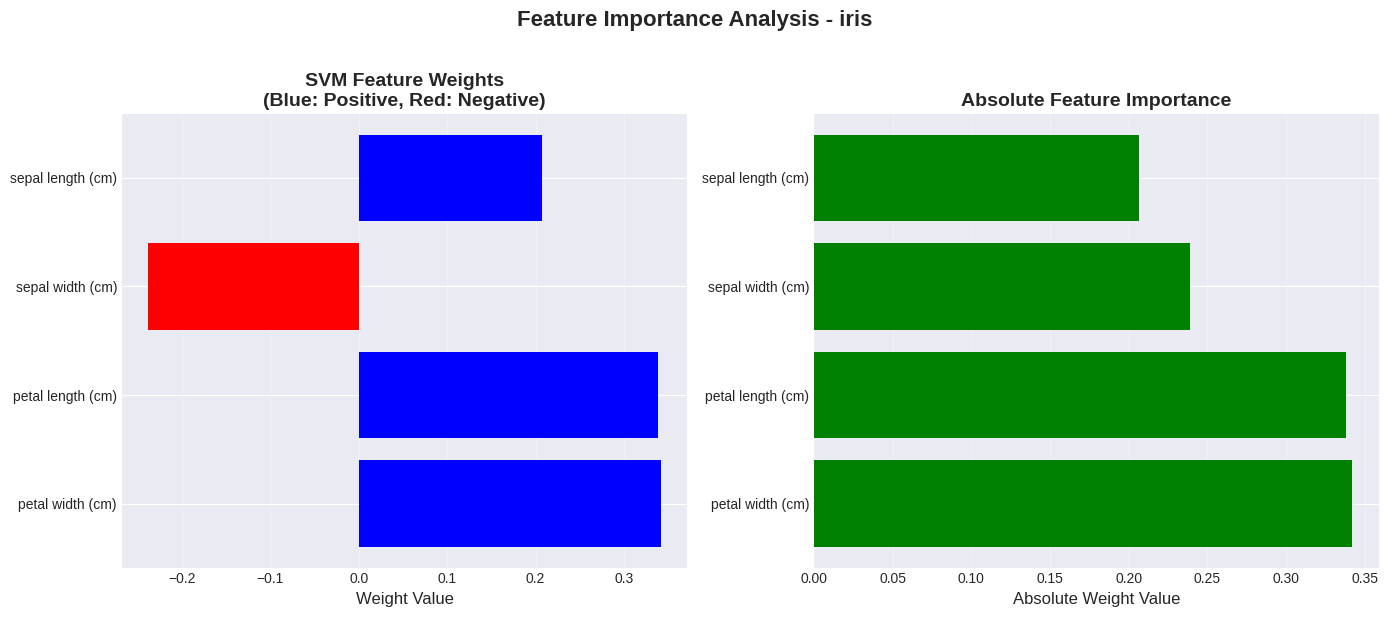


######################################################################
ANALYZING DATASET: cancer
######################################################################
Description: Breast Cancer Wisconsin (Diagnostic) Dataset
Shape: X=(569, 30), y=(569,)
Classes: ['malignant' 'benign']

COMPARING HARD VS SOFT MARGIN SVM: cancer

Hard Margin (C=∞):
----------------------------------------
  Train Accuracy: 1.0000
  Test Accuracy:  0.9415
  Margin Width:   0.0816
  Support Vectors: 26
  Norm of w:      24.5117

Soft Margin (C=0.1):
----------------------------------------
  Train Accuracy: 0.9799
  Test Accuracy:  0.9708
  Margin Width:   1.5240
  Support Vectors: 42
  Norm of w:      1.3124
  Margin Violators (train): 168
  Margin Violators (test):  82

Soft Margin (C=10):
----------------------------------------
  Train Accuracy: 0.9925
  Test Accuracy:  0.9532
  Margin Width:   0.2647
  Support Vectors: 25
  Norm of w:      7.5553
  Margin Violators (train): 155
  Margin Violators (t

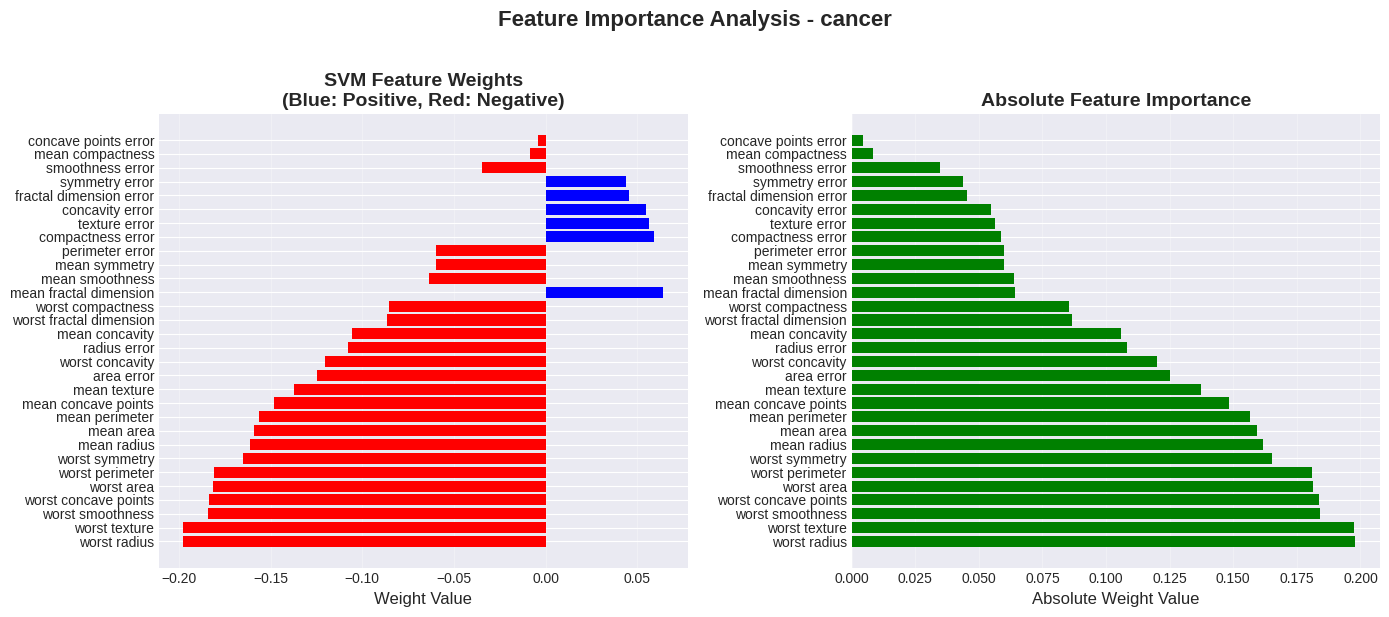


######################################################################
ANALYZING DATASET: wine
######################################################################
Description: Wine Class 0 vs Class 1 (13 features)
Shape: X=(130, 13), y=(130,)
Classes: ['class_0' 'class_1']

COMPARING HARD VS SOFT MARGIN SVM: wine

Hard Margin (C=∞):
----------------------------------------
  Train Accuracy: 1.0000
  Test Accuracy:  0.9744
  Margin Width:   1.3510
  Support Vectors: 11
  Norm of w:      1.4804

Soft Margin (C=0.1):
----------------------------------------
  Train Accuracy: 1.0000
  Test Accuracy:  0.9487
  Margin Width:   1.7722
  Support Vectors: 20
  Norm of w:      1.1285
  Margin Violators (train): 51
  Margin Violators (test):  27

Soft Margin (C=10):
----------------------------------------
  Train Accuracy: 1.0000
  Test Accuracy:  0.9744
  Margin Width:   1.3510
  Support Vectors: 11
  Norm of w:      1.4804
  Margin Violators (train): 45
  Margin Violators (test):  25

SUMM

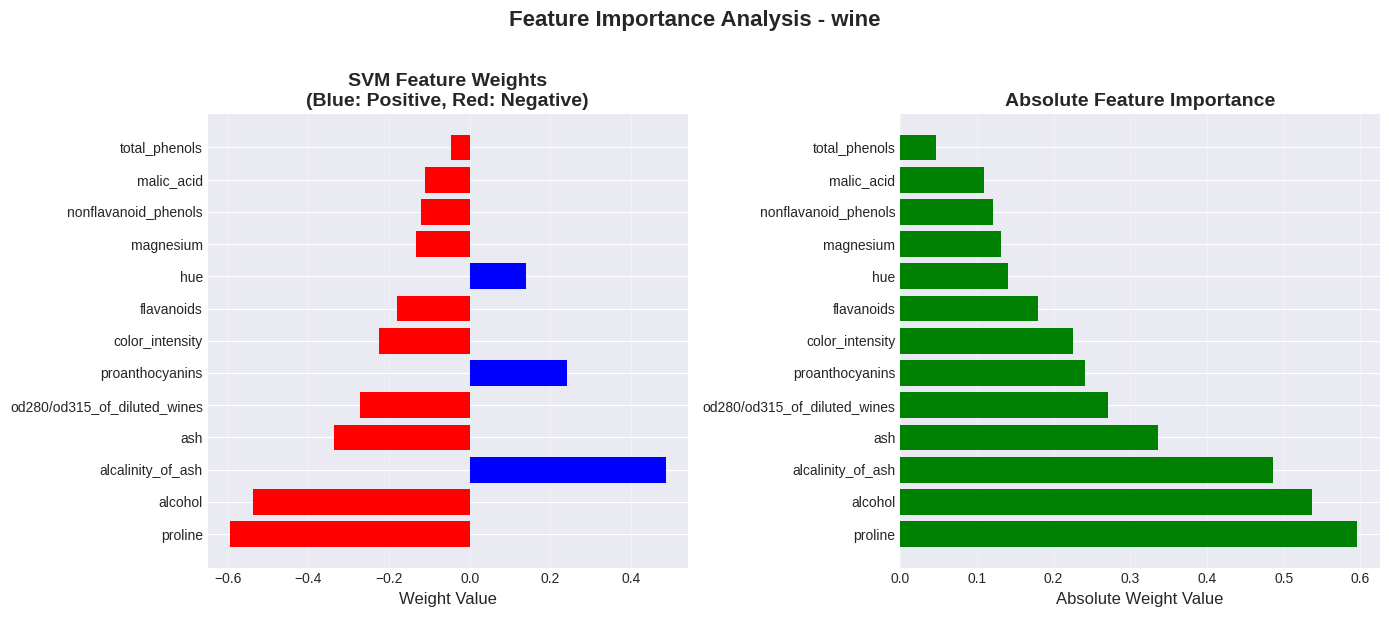


######################################################################
ANALYZING DATASET: linear_separable
######################################################################
Description: Synthetic Linearly Separable Data
Shape: X=(200, 2), y=(200,)
Classes: ['Class 0', 'Class 1']

COMPARING HARD VS SOFT MARGIN SVM: linear_separable

Hard Margin (C=∞):
----------------------------------------
  Train Accuracy: 0.9714
  Test Accuracy:  1.0000
  Margin Width:   0.0007
  Support Vectors: 9
  Norm of w:      3071.1582

Soft Margin (C=0.1):
----------------------------------------
  Train Accuracy: 0.9643
  Test Accuracy:  1.0000
  Margin Width:   1.3335
  Support Vectors: 44
  Norm of w:      1.4999
  Margin Violators (train): 91
  Margin Violators (test):  39

Soft Margin (C=10):
----------------------------------------
  Train Accuracy: 0.9643
  Test Accuracy:  1.0000
  Margin Width:   0.6186
  Support Vectors: 15
  Norm of w:      3.2329
  Margin Violators (train): 76
  Margin Viola

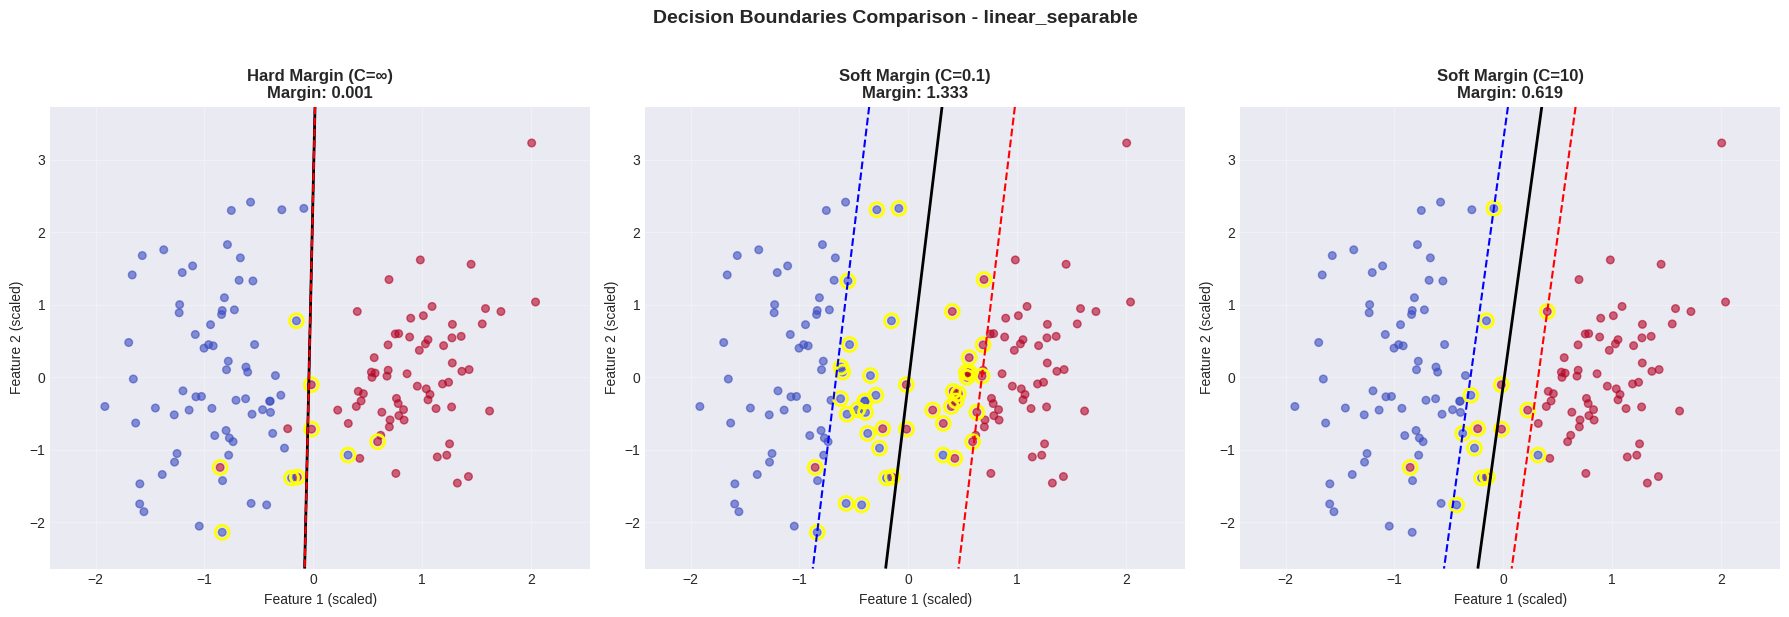


C PARAMETER ANALYSIS: linear_separable
C=0.001    | Train Acc: 0.9571 | Test Acc: 0.9667 | Margin: 16.2613 | SVs: 140
C=0.01     | Train Acc: 0.9643 | Test Acc: 1.0000 | Margin: 2.5719 | SVs: 110
C=0.1      | Train Acc: 0.9643 | Test Acc: 1.0000 | Margin: 1.3335 | SVs: 44
C=1        | Train Acc: 0.9643 | Test Acc: 1.0000 | Margin: 0.7872 | SVs: 20
C=10       | Train Acc: 0.9643 | Test Acc: 1.0000 | Margin: 0.6186 | SVs: 15
C=100      | Train Acc: 0.9643 | Test Acc: 1.0000 | Margin: 0.6187 | SVs: 15
C=1000     | Train Acc: 0.9643 | Test Acc: 1.0000 | Margin: 0.6191 | SVs: 15
C=10000    | Train Acc: 0.9643 | Test Acc: 1.0000 | Margin: 0.6072 | SVs: 14


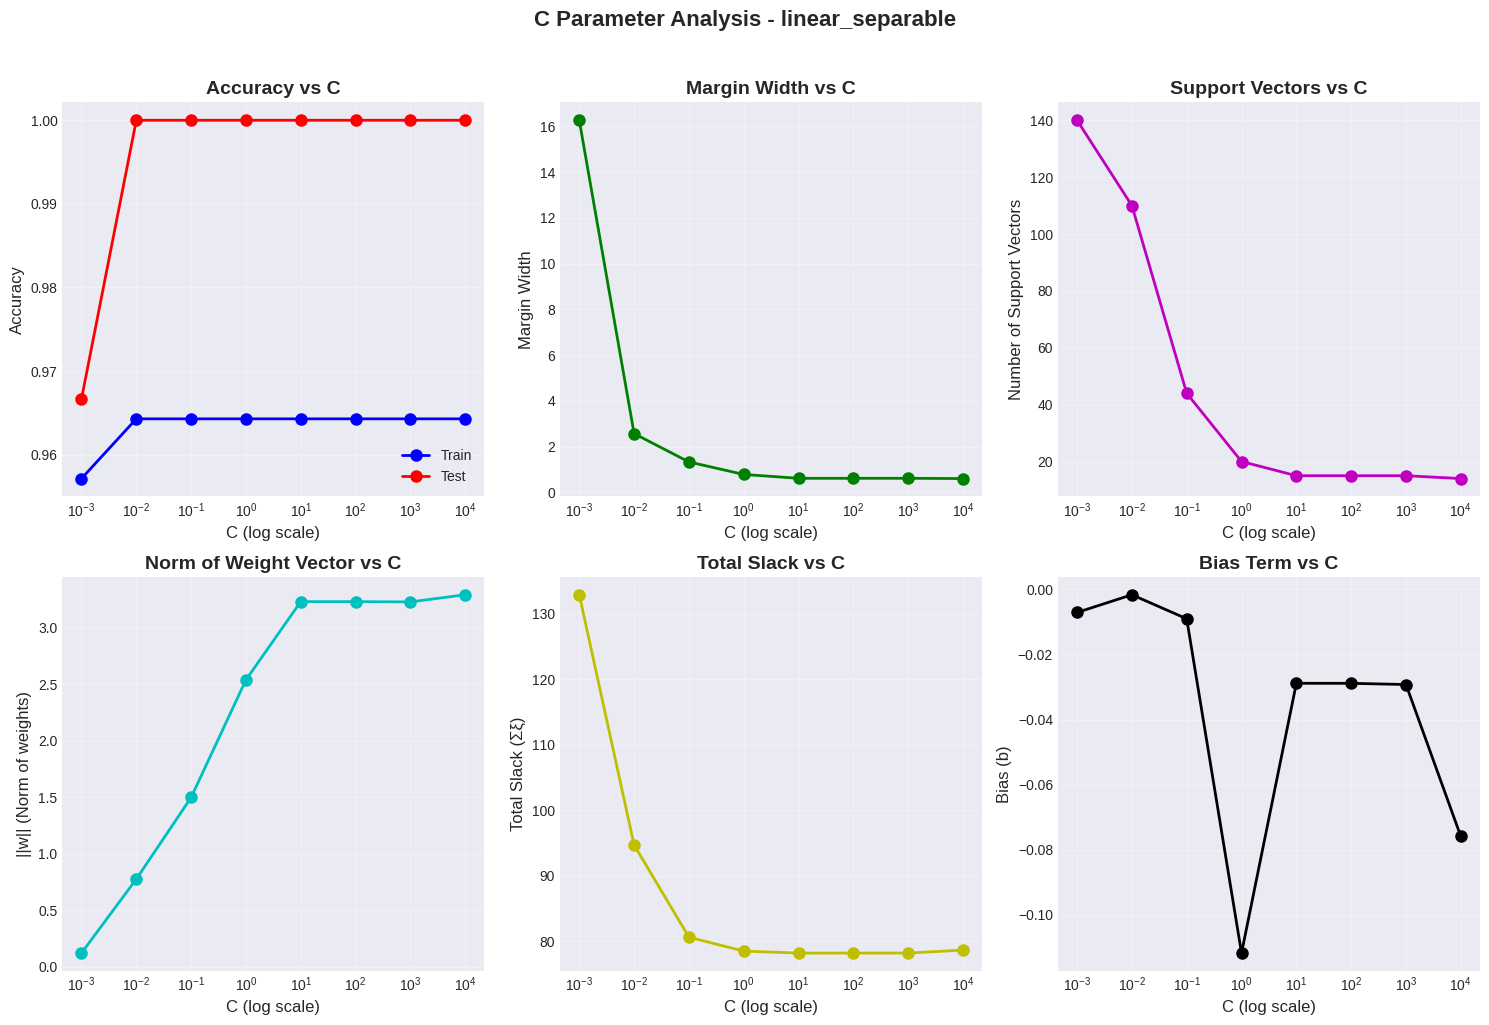


######################################################################
ANALYZING DATASET: non_linear
######################################################################
Description: Synthetic Non-linearly Separable Data
Shape: X=(200, 2), y=(200,)
Classes: ['Class 0', 'Class 1']

COMPARING HARD VS SOFT MARGIN SVM: non_linear

Hard Margin (C=∞):
----------------------------------------
  Train Accuracy: 0.7071
  Test Accuracy:  0.8667
  Margin Width:   0.0009
  Support Vectors: 62
  Norm of w:      2238.0940

Soft Margin (C=0.1):
----------------------------------------
  Train Accuracy: 0.7143
  Test Accuracy:  0.9333
  Margin Width:   2.0661
  Support Vectors: 105
  Norm of w:      0.9680
  Margin Violators (train): 121
  Margin Violators (test):  49

Soft Margin (C=10):
----------------------------------------
  Train Accuracy: 0.7143
  Test Accuracy:  0.9000
  Margin Width:   1.7968
  Support Vectors: 94
  Norm of w:      1.1131
  Margin Violators (train): 116
  Margin Violators

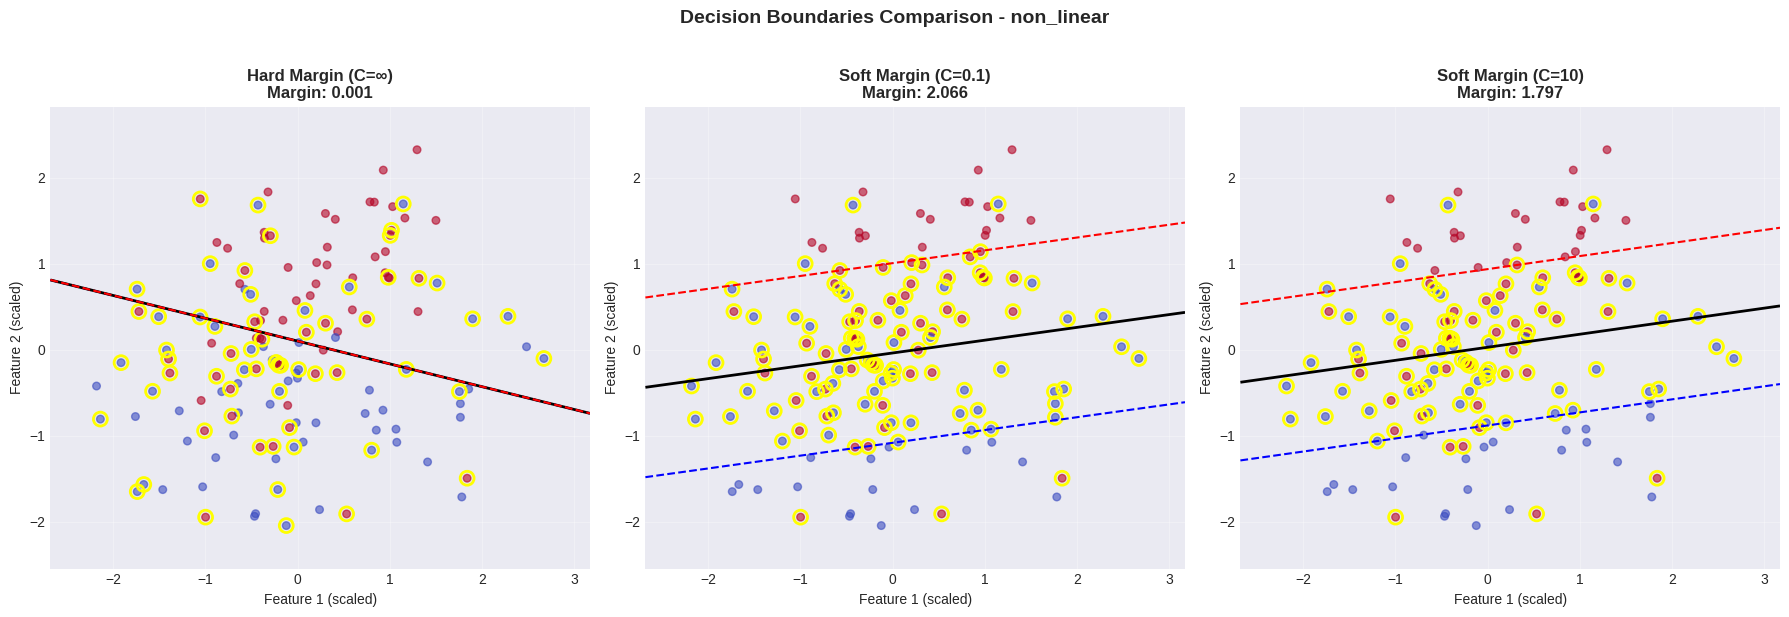


C PARAMETER ANALYSIS: non_linear
C=0.001    | Train Acc: 0.5071 | Test Acc: 0.5000 | Margin: 32.2817 | SVs: 138
C=0.01     | Train Acc: 0.7071 | Test Acc: 0.9000 | Margin: 3.6936 | SVs: 134
C=0.1      | Train Acc: 0.7143 | Test Acc: 0.9333 | Margin: 2.0661 | SVs: 105
C=1        | Train Acc: 0.7143 | Test Acc: 0.9000 | Margin: 1.8054 | SVs: 95
C=10       | Train Acc: 0.7143 | Test Acc: 0.9000 | Margin: 1.7968 | SVs: 94
C=100      | Train Acc: 0.7143 | Test Acc: 0.9000 | Margin: 1.7966 | SVs: 94
C=1000     | Train Acc: 0.7143 | Test Acc: 0.9000 | Margin: 1.7971 | SVs: 94
C=10000    | Train Acc: 0.7143 | Test Acc: 0.9000 | Margin: 1.8005 | SVs: 94


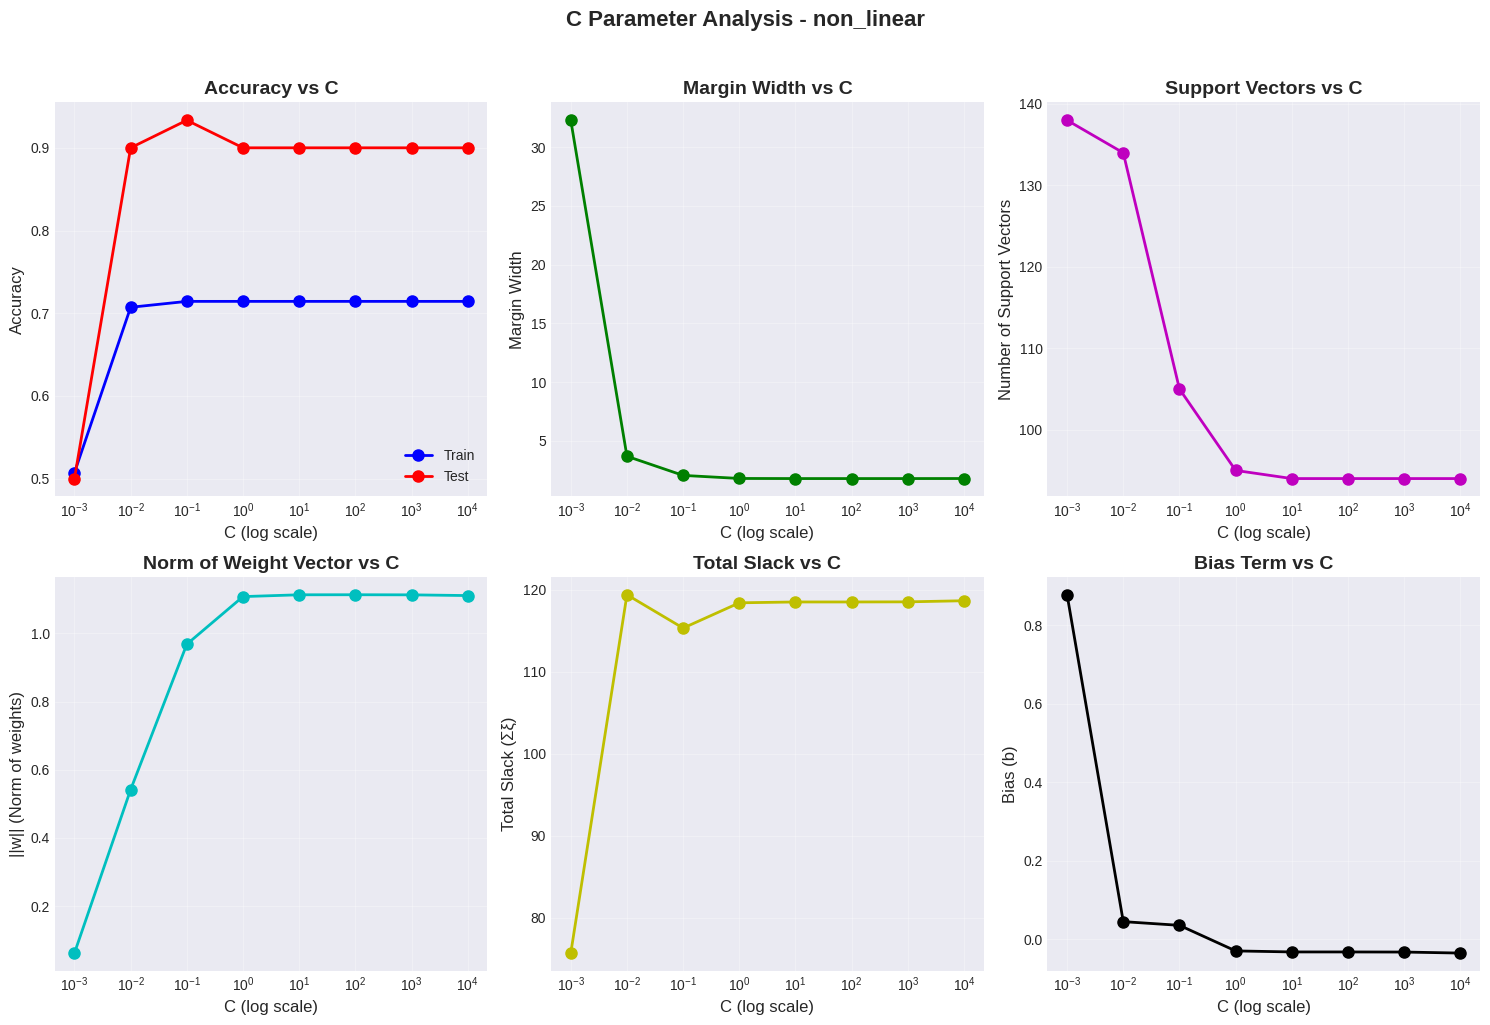


######################################################################
CREATING COMPREHENSIVE VISUALIZATION
######################################################################


AttributeError: 'HardMarginSVM' object has no attribute 'support_vectors_'

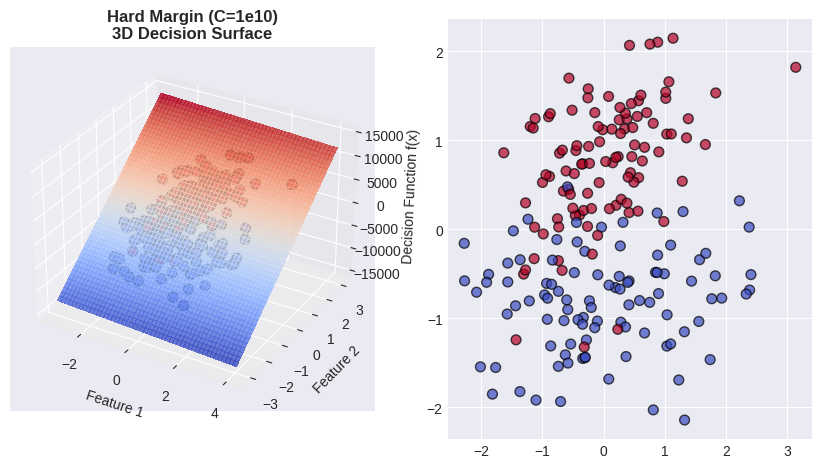

In [8]:
"""
Complete Implementation of Soft and Hard Margin Linear SVM
Using sklearn's SVM with open-source datasets
Author: ML Expert
Date: 2024
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                           accuracy_score, precision_score, recall_score,
                           roc_curve, auc, RocCurveDisplay)
from sklearn.inspection import DecisionBoundaryDisplay
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ======================================================================
# 1. LOAD AND PREPARE DATASETS
# ======================================================================

def load_datasets():
    """
    Load multiple open-source datasets for SVM demonstration
    """
    datasets_dict = {}

    # 1. Iris dataset (binary classification - setosa vs versicolor)
    print("Loading Iris dataset...")
    iris = datasets.load_iris()
    # Use only first two classes for binary classification
    X_iris = iris.data[iris.target != 2]
    y_iris = iris.target[iris.target != 2]
    datasets_dict['iris'] = {
        'X': X_iris, 'y': y_iris,
        'feature_names': iris.feature_names,
        'target_names': iris.target_names[:2],
        'description': 'Iris Setosa vs Versicolor (4 features)'
    }

    # 2. Breast Cancer dataset
    print("Loading Breast Cancer dataset...")
    cancer = datasets.load_breast_cancer()
    datasets_dict['cancer'] = {
        'X': cancer.data, 'y': cancer.target,
        'feature_names': cancer.feature_names,
        'target_names': cancer.target_names,
        'description': 'Breast Cancer Wisconsin (Diagnostic) Dataset'
    }

    # 3. Wine dataset (binary: class 0 vs class 1)
    print("Loading Wine dataset...")
    wine = datasets.load_wine()
    X_wine = wine.data[wine.target != 2]
    y_wine = wine.target[wine.target != 2]
    datasets_dict['wine'] = {
        'X': X_wine, 'y': y_wine,
        'feature_names': wine.feature_names,
        'target_names': wine.target_names[:2],
        'description': 'Wine Class 0 vs Class 1 (13 features)'
    }

    # 4. Make synthetic linearly separable data
    print("Creating synthetic datasets...")
    X_lin_sep, y_lin_sep = datasets.make_classification(
        n_samples=200, n_features=2, n_informative=2, n_redundant=0,
        n_clusters_per_class=1, flip_y=0, class_sep=2.0, random_state=42
    )
    datasets_dict['linear_separable'] = {
        'X': X_lin_sep, 'y': y_lin_sep,
        'feature_names': ['Feature 1', 'Feature 2'],
        'target_names': ['Class 0', 'Class 1'],
        'description': 'Synthetic Linearly Separable Data'
    }

    # 5. Make synthetic non-linearly separable data
    X_nonlin, y_nonlin = datasets.make_classification(
        n_samples=200, n_features=2, n_informative=2, n_redundant=0,
        n_clusters_per_class=1, flip_y=0.1, class_sep=1.0, random_state=42
    )
    # Add some noise to make it more challenging
    X_nonlin += np.random.normal(0, 0.3, X_nonlin.shape)
    datasets_dict['non_linear'] = {
        'X': X_nonlin, 'y': y_nonlin,
        'feature_names': ['Feature 1', 'Feature 2'],
        'target_names': ['Class 0', 'Class 1'],
        'description': 'Synthetic Non-linearly Separable Data'
    }

    return datasets_dict

# ======================================================================
# 2. HARD MARGIN SVM IMPLEMENTATION
# ======================================================================

class HardMarginSVM:
    """
    Implementation of Hard Margin Linear SVM
    Uses very large C to approximate hard margin
    """

    def __init__(self, C=1e10, random_state=42):
        """
        Initialize Hard Margin SVM

        Parameters:
        -----------
        C : float, default=1e10
            Very large C approximates hard margin
            (Hard margin requires C → ∞)
        random_state : int
            Random seed for reproducibility
        """
        self.C = C
        self.model = svm.SVC(
            kernel='linear',
            C=C,
            random_state=random_state,
            probability=False
        )
        self.is_fitted = False

    def fit(self, X, y):
        """Fit the hard margin SVM"""
        self.model.fit(X, y)
        self.is_fitted = True

        # Extract learned parameters
        self.w = self.model.coef_[0]
        self.b = self.model.intercept_[0]
        self.support_vectors = self.model.support_vectors_
        self.support_vector_indices = self.model.support_
        self.n_support_vectors = len(self.support_vectors)

        return self

    def predict(self, X):
        """Predict class labels"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.model.predict(X)

    def decision_function(self, X):
        """Return signed distance to hyperplane"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.model.decision_function(X)

    def get_margin(self):
        """Calculate the margin width"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        margin = 2.0 / np.linalg.norm(self.w)
        return margin

    def get_parameters(self):
        """Get all learned parameters"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")

        return {
            'weight_vector': self.w,
            'bias': self.b,
            'margin': self.get_margin(),
            'n_support_vectors': self.n_support_vectors,
            'support_vectors': self.support_vectors,
            'support_vector_indices': self.support_vector_indices,
            'norm_of_w': np.linalg.norm(self.w)
        }

    def plot_decision_boundary(self, X, y, title="Hard Margin SVM"):
        """Plot decision boundary and margin (for 2D data only)"""
        if X.shape[1] != 2:
            print("Warning: Can only plot for 2D data")
            return

        fig, ax = plt.subplots(figsize=(10, 7))

        # Plot data points
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
                           s=50, edgecolors='k', alpha=0.7, label='Data Points')

        # Highlight support vectors
        ax.scatter(self.support_vectors[:, 0], self.support_vectors[:, 1],
                  s=200, facecolors='none', edgecolors='yellow',
                  linewidths=2, label='Support Vectors')

        # Create grid for decision boundary
        xx, yy = np.meshgrid(
            np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
            np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
        )

        # Get predictions for grid
        Z = self.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot decision boundary and margins
        ax.contour(xx, yy, Z, levels=[-1, 0, 1],
                  linestyles=['--', '-', '--'],
                  colors=['blue', 'black', 'red'],
                  linewidths=[2, 2, 2])

        # Fill margin area
        ax.contourf(xx, yy, Z, levels=[-1, 1],
                   colors=['blue', 'red'], alpha=0.1)

        ax.set_xlabel('Feature 1', fontsize=12)
        ax.set_ylabel('Feature 2', fontsize=12)
        ax.set_title(f'{title}\nMargin Width: {self.get_margin():.3f}',
                    fontsize=14, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig, ax

# ======================================================================
# 3. SOFT MARGIN SVM IMPLEMENTATION
# ======================================================================

class SoftMarginSVM:
    """
    Implementation of Soft Margin Linear SVM with varying C
    """

    def __init__(self, C=1.0, random_state=42):
        """
        Initialize Soft Margin SVM

        Parameters:
        -----------
        C : float, default=1.0
            Regularization parameter
            Small C: larger margin, more errors allowed
            Large C: smaller margin, fewer errors allowed
        random_state : int
            Random seed for reproducibility
        """
        self.C = C
        self.model = svm.SVC(
            kernel='linear',
            C=C,
            random_state=random_state,
            probability=True
        )
        self.is_fitted = False

    def fit(self, X, y):
        """Fit the soft margin SVM"""
        self.model.fit(X, y)
        self.is_fitted = True

        # Extract learned parameters
        self.w = self.model.coef_[0]
        self.b = self.model.intercept_[0]
        self.support_vectors = self.model.support_vectors_
        self.support_vector_indices = self.model.support_
        self.n_support_vectors = len(self.support_vectors)

        # Get dual coefficients (alphas)
        self.dual_coef_ = self.model.dual_coef_[0]

        return self

    def predict(self, X):
        """Predict class labels"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.model.predict(X)

    def predict_proba(self, X):
        """Predict class probabilities"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.model.predict_proba(X)

    def decision_function(self, X):
        """Return signed distance to hyperplane"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.model.decision_function(X)

    def get_margin(self):
        """Calculate the margin width"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")
        margin = 2.0 / np.linalg.norm(self.w)
        return margin

    def get_slack_variables(self, X, y):
        """
        Calculate slack variables for each data point
        ξ_i = max(0, 1 - y_i(w·x_i + b))
        """
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")

        distances = y * self.decision_function(X)
        slack = np.maximum(0, 1 - distances)
        return slack

    def get_parameters(self):
        """Get all learned parameters"""
        if not self.is_fitted:
            raise ValueError("Model not fitted yet. Call fit() first.")

        return {
            'weight_vector': self.w,
            'bias': self.b,
            'margin': self.get_margin(),
            'n_support_vectors': self.n_support_vectors,
            'support_vectors': self.support_vectors,
            'support_vector_indices': self.support_vector_indices,
            'dual_coefficients': self.dual_coef_,
            'norm_of_w': np.linalg.norm(self.w),
            'C': self.C
        }

    def plot_decision_boundary(self, X, y, title="Soft Margin SVM"):
        """Plot decision boundary and margin (for 2D data only)"""
        if X.shape[1] != 2:
            print("Warning: Can only plot for 2D data")
            return

        fig, ax = plt.subplots(figsize=(10, 7))

        # Calculate slack variables
        slack = self.get_slack_variables(X, y)

        # Plot data points with size proportional to slack
        scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
                           s=30 + 100 * slack,  # Larger points have more slack
                           edgecolors='k', alpha=0.7, label='Data Points')

        # Highlight support vectors
        ax.scatter(self.support_vectors[:, 0], self.support_vectors[:, 1],
                  s=200, facecolors='none', edgecolors='yellow',
                  linewidths=2, label='Support Vectors')

        # Highlight points with slack > 0
        slack_points = X[slack > 0]
        if len(slack_points) > 0:
            ax.scatter(slack_points[:, 0], slack_points[:, 1],
                      s=300, facecolors='none', edgecolors='orange',
                      linewidths=2, label='Margin Violators (ξ > 0)')

        # Create grid for decision boundary
        xx, yy = np.meshgrid(
            np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
            np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
        )

        # Get predictions for grid
        Z = self.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot decision boundary and margins
        ax.contour(xx, yy, Z, levels=[-1, 0, 1],
                  linestyles=['--', '-', '--'],
                  colors=['blue', 'black', 'red'],
                  linewidths=[2, 2, 2])

        # Fill margin area
        ax.contourf(xx, yy, Z, levels=[-1, 1],
                   colors=['blue', 'red'], alpha=0.1)

        ax.set_xlabel('Feature 1', fontsize=12)
        ax.set_ylabel('Feature 2', fontsize=12)
        ax.set_title(f'{title} (C={self.C})\nMargin Width: {self.get_margin():.3f}',
                    fontsize=14, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig, ax

# ======================================================================
# 4. COMPARATIVE ANALYSIS FUNCTIONS
# ======================================================================

def compare_hard_vs_soft(X, y, dataset_name, feature_names=None):
    """
    Compare Hard Margin vs Soft Margin SVM on the same dataset
    """
    print(f"\n{'='*60}")
    print(f"COMPARING HARD VS SOFT MARGIN SVM: {dataset_name}")
    print(f"{'='*60}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Scale features (important for SVM)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize models
    hard_svm = HardMarginSVM(C=1e10)  # Very large C for hard margin
    soft_svm_small_c = SoftMarginSVM(C=0.1)  # Small C for large margin
    soft_svm_large_c = SoftMarginSVM(C=10.0)  # Large C for small margin

    models = {
        'Hard Margin (C=∞)': hard_svm,
        'Soft Margin (C=0.1)': soft_svm_small_c,
        'Soft Margin (C=10)': soft_svm_large_c
    }

    results = []

    # Train and evaluate each model
    for name, model in models.items():
        print(f"\n{name}:")
        print("-" * 40)

        # Train model
        model.fit(X_train_scaled, y_train)

        # Get parameters
        params = model.get_parameters()

        # Predict
        y_pred = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)

        # Calculate metrics
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')

        # Calculate slack if applicable
        if hasattr(model, 'get_slack_variables'):
            slack_train = model.get_slack_variables(X_train_scaled, y_train)
            slack_test = model.get_slack_variables(X_test_scaled, y_test)
            n_violators_train = np.sum(slack_train > 0)
            n_violators_test = np.sum(slack_test > 0)
        else:
            n_violators_train = n_violators_test = 0

        # Store results
        results.append({
            'Model': name,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Precision': precision,
            'Recall': recall,
            'Margin Width': params['margin'],
            'N Support Vectors': params['n_support_vectors'],
            'Norm of w': params['norm_of_w'],
            'Train Violators': n_violators_train,
            'Test Violators': n_violators_test,
            'Bias (b)': params['bias']
        })

        print(f"  Train Accuracy: {train_acc:.4f}")
        print(f"  Test Accuracy:  {test_acc:.4f}")
        print(f"  Margin Width:   {params['margin']:.4f}")
        print(f"  Support Vectors: {params['n_support_vectors']}")
        print(f"  Norm of w:      {params['norm_of_w']:.4f}")
        if hasattr(model, 'get_slack_variables'):
            print(f"  Margin Violators (train): {n_violators_train}")
            print(f"  Margin Violators (test):  {n_violators_test}")

    # Create comparison DataFrame
    results_df = pd.DataFrame(results)

    # Display comparison table
    print(f"\n{'='*60}")
    print("SUMMARY COMPARISON:")
    print(f"{'='*60}")
    display_cols = ['Model', 'Train Accuracy', 'Test Accuracy',
                   'Margin Width', 'N Support Vectors',
                   'Train Violators', 'Test Violators']
    print(results_df[display_cols].to_string(index=False))

    # Plot comparison if data is 2D
    if X.shape[1] == 2:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        for idx, (name, model) in enumerate(models.items()):
            ax = axes[idx]

            # Plot data
            scatter = ax.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
                               c=y_train, cmap='coolwarm', s=30, alpha=0.6)

            # Highlight support vectors
            sv = model.support_vectors
            ax.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none',
                      edgecolors='yellow', linewidths=2)

            # Create grid for decision boundary
            xx, yy = np.meshgrid(
                np.linspace(X_train_scaled[:, 0].min() - 0.5,
                           X_train_scaled[:, 0].max() + 0.5, 100),
                np.linspace(X_train_scaled[:, 1].min() - 0.5,
                           X_train_scaled[:, 1].max() + 0.5, 100)
            )

            # Get decision function values
            Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)

            # Plot decision boundary and margins
            ax.contour(xx, yy, Z, levels=[-1, 0, 1],
                      linestyles=['--', '-', '--'],
                      colors=['blue', 'black', 'red'],
                      linewidths=[1.5, 2, 1.5])

            ax.set_xlabel('Feature 1 (scaled)', fontsize=10)
            ax.set_ylabel('Feature 2 (scaled)', fontsize=10)
            ax.set_title(f'{name}\nMargin: {results[idx]["Margin Width"]:.3f}',
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)

        plt.suptitle(f'Decision Boundaries Comparison - {dataset_name}',
                    fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    return results_df, models

# ======================================================================
# 5. C PARAMETER ANALYSIS
# ======================================================================

def analyze_c_parameter(X, y, dataset_name):
    """
    Analyze the effect of C parameter on Soft Margin SVM
    """
    print(f"\n{'='*60}")
    print(f"C PARAMETER ANALYSIS: {dataset_name}")
    print(f"{'='*60}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Test different C values
    C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
    results = []

    for C in C_values:
        # Create and train model
        model = SoftMarginSVM(C=C)
        model.fit(X_train_scaled, y_train)

        # Get parameters
        params = model.get_parameters()

        # Predict
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)

        # Calculate metrics
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)

        # Calculate slack
        slack_train = model.get_slack_variables(X_train_scaled, y_train)
        total_slack = np.sum(slack_train)

        # Store results
        results.append({
            'C': C,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Margin Width': params['margin'],
            'N Support Vectors': params['n_support_vectors'],
            'Norm of w': params['norm_of_w'],
            'Total Slack': total_slack,
            'Bias (b)': params['bias']
        })

        print(f"C={C:<8} | Train Acc: {train_acc:.4f} | "
              f"Test Acc: {test_acc:.4f} | Margin: {params['margin']:.4f} | "
              f"SVs: {params['n_support_vectors']}")

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Plot C analysis
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # 1. Accuracy vs C
    axes[0, 0].semilogx(results_df['C'], results_df['Train Accuracy'],
                       'bo-', linewidth=2, markersize=8, label='Train')
    axes[0, 0].semilogx(results_df['C'], results_df['Test Accuracy'],
                       'ro-', linewidth=2, markersize=8, label='Test')
    axes[0, 0].set_xlabel('C (log scale)', fontsize=12)
    axes[0, 0].set_ylabel('Accuracy', fontsize=12)
    axes[0, 0].set_title('Accuracy vs C', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Margin vs C
    axes[0, 1].semilogx(results_df['C'], results_df['Margin Width'],
                       'go-', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('C (log scale)', fontsize=12)
    axes[0, 1].set_ylabel('Margin Width', fontsize=12)
    axes[0, 1].set_title('Margin Width vs C', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Support Vectors vs C
    axes[0, 2].semilogx(results_df['C'], results_df['N Support Vectors'],
                       'mo-', linewidth=2, markersize=8)
    axes[0, 2].set_xlabel('C (log scale)', fontsize=12)
    axes[0, 2].set_ylabel('Number of Support Vectors', fontsize=12)
    axes[0, 2].set_title('Support Vectors vs C', fontsize=14, fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Norm of w vs C
    axes[1, 0].semilogx(results_df['C'], results_df['Norm of w'],
                       'co-', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('C (log scale)', fontsize=12)
    axes[1, 0].set_ylabel('||w|| (Norm of weights)', fontsize=12)
    axes[1, 0].set_title('Norm of Weight Vector vs C', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Total Slack vs C
    axes[1, 1].semilogx(results_df['C'], results_df['Total Slack'],
                       'yo-', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('C (log scale)', fontsize=12)
    axes[1, 1].set_ylabel('Total Slack (Σξ)', fontsize=12)
    axes[1, 1].set_title('Total Slack vs C', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Bias vs C
    axes[1, 2].semilogx(results_df['C'], results_df['Bias (b)'],
                       'ko-', linewidth=2, markersize=8)
    axes[1, 2].set_xlabel('C (log scale)', fontsize=12)
    axes[1, 2].set_ylabel('Bias (b)', fontsize=12)
    axes[1, 2].set_title('Bias Term vs C', fontsize=14, fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)

    plt.suptitle(f'C Parameter Analysis - {dataset_name}',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return results_df

# ======================================================================
# 6. FEATURE IMPORTANCE AND INTERPRETATION
# ======================================================================

def analyze_feature_importance(X, y, feature_names, dataset_name):
    """
    Analyze feature importance from SVM weights
    """
    print(f"\n{'='*60}")
    print(f"FEATURE IMPORTANCE ANALYSIS: {dataset_name}")
    print(f"{'='*60}")

    # Split and scale data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Train SVM with optimal C (using cross-validation)
    param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
    grid_search = GridSearchCV(
        svm.SVC(kernel='linear', random_state=42),
        param_grid, cv=5, scoring='accuracy'
    )
    grid_search.fit(X_train_scaled, y_train)

    best_svm = grid_search.best_estimator_
    best_C = grid_search.best_params_['C']

    print(f"Best C from cross-validation: {best_C}")
    print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

    # Get feature weights
    weights = best_svm.coef_[0]

    # Create feature importance DataFrame
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Weight': weights,
        'Absolute Weight': np.abs(weights)
    })

    # Sort by absolute weight
    feature_importance = feature_importance.sort_values('Absolute Weight',
                                                       ascending=False)

    print("\nFeature Importance (sorted by absolute weight):")
    print("-" * 60)
    for idx, row in feature_importance.iterrows():
        print(f"{row['Feature']:30} | Weight: {row['Weight']:10.6f} | "
              f"Abs: {row['Absolute Weight']:10.6f}")

    # Plot feature importance
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Bar plot of weights
    colors = ['red' if w < 0 else 'blue' for w in feature_importance['Weight']]
    ax1.barh(range(len(feature_importance)),
             feature_importance['Weight'], color=colors)
    ax1.set_yticks(range(len(feature_importance)))
    ax1.set_yticklabels(feature_importance['Feature'])
    ax1.set_xlabel('Weight Value', fontsize=12)
    ax1.set_title('SVM Feature Weights\n(Blue: Positive, Red: Negative)',
                 fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')

    # Bar plot of absolute weights
    ax2.barh(range(len(feature_importance)),
             feature_importance['Absolute Weight'], color='green')
    ax2.set_yticks(range(len(feature_importance)))
    ax2.set_yticklabels(feature_importance['Feature'])
    ax2.set_xlabel('Absolute Weight Value', fontsize=12)
    ax2.set_title('Absolute Feature Importance',
                 fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')

    plt.suptitle(f'Feature Importance Analysis - {dataset_name}',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return feature_importance, best_svm

# ======================================================================
# 7. VISUALIZATION OF DECISION BOUNDARIES
# ======================================================================

def visualize_decision_boundaries():
    """
    Create comprehensive visualization of SVM decision boundaries
    """
    # Create synthetic dataset
    X, y = datasets.make_classification(
        n_samples=200, n_features=2, n_informative=2, n_redundant=0,
        n_clusters_per_class=1, flip_y=0.05, class_sep=1.5, random_state=42
    )

    # Add some noise
    X += np.random.normal(0, 0.3, X.shape)

    # Scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train different models
    models = {
        'Hard Margin (C=1e10)': HardMarginSVM(C=1e10),
        'Soft Margin (C=0.01)': SoftMarginSVM(C=0.01),
        'Soft Margin (C=1)': SoftMarginSVM(C=1),
        'Soft Margin (C=100)': SoftMarginSVM(C=100)
    }

    # Fit all models
    for name, model in models.items():
        model.fit(X_scaled, y)

    # Create visualization grid
    fig = plt.figure(figsize=(16, 12))

    # Create 3D plot for first model
    ax1 = fig.add_subplot(231, projection='3d')
    model_name = list(models.keys())[0]
    model = models[model_name]

    # Create mesh for 3D plot
    xx, yy = np.meshgrid(
        np.linspace(X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1, 50),
        np.linspace(X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1, 50)
    )

    # Calculate decision function values
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot 3D surface
    surf = ax1.plot_surface(xx, yy, Z, cmap='coolwarm', alpha=0.8,
                           linewidth=0, antialiased=False)

    # Plot data points
    ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], model.decision_function(X_scaled),
               c=y, cmap='coolwarm', s=50, edgecolors='k', depthshade=False)

    ax1.set_xlabel('Feature 1', fontsize=10)
    ax1.set_ylabel('Feature 2', fontsize=10)
    ax1.set_zlabel('Decision Function f(x)', fontsize=10)
    ax1.set_title(f'{model_name}\n3D Decision Surface', fontsize=12, fontweight='bold')

    # Plot 2D decision boundaries for all models
    for idx, (name, model) in enumerate(models.items(), start=2):
        ax = fig.add_subplot(2, 3, idx)

        # Plot data points
        ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm',
                  s=50, edgecolors='k', alpha=0.7)

        # Highlight support vectors
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=200, facecolors='none',
                  edgecolors='yellow', linewidths=2, label='Support Vectors')

        # Create contour plot
        xx, yy = np.meshgrid(
            np.linspace(X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1, 100),
            np.linspace(X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1, 100)
        )

        Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot decision boundary and margins
        ax.contour(xx, yy, Z, levels=[-1, 0, 1],
                  linestyles=['--', '-', '--'],
                  colors=['blue', 'black', 'red'],
                  linewidths=[1.5, 2, 1.5])

        # Fill margin area
        ax.contourf(xx, yy, Z, levels=[-1, 1],
                   colors=['blue', 'red'], alpha=0.1)

        ax.set_xlabel('Feature 1 (scaled)', fontsize=10)
        ax.set_ylabel('Feature 2 (scaled)', fontsize=10)
        ax.set_title(f'{name}\nMargin: {model.get_margin():.3f}',
                    fontsize=12, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

    # Add one more subplot for comparison summary
    ax_summary = fig.add_subplot(2, 3, 6)
    ax_summary.axis('off')

    # Create summary text
    summary_text = "SVM MARGIN COMPARISON:\n\n"
    for name, model in models.items():
        params = model.get_parameters()
        summary_text += f"{name}:\n"
        summary_text += f"  Margin: {params['margin']:.3f}\n"
        summary_text += f"  SVs: {params['n_support_vectors']}\n"
        summary_text += f"  ||w||: {params['norm_of_w']:.3f}\n\n"

    ax_summary.text(0.1, 0.5, summary_text, fontsize=11,
                   verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('Comprehensive SVM Decision Boundary Visualization',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# ======================================================================
# 8. MAIN EXECUTION FUNCTION
# ======================================================================

def main():
    """
    Main function to run all SVM analyses
    """
    print("=" * 70)
    print("COMPREHENSIVE SVM IMPLEMENTATION: HARD vs SOFT MARGIN")
    print("=" * 70)

    # Load datasets
    datasets_dict = load_datasets()

    # Dictionary to store all results
    all_results = {}

    # Analyze each dataset
    for dataset_name, data in datasets_dict.items():
        print(f"\n{'#' * 70}")
        print(f"ANALYZING DATASET: {dataset_name}")
        print(f"{'#' * 70}")
        print(f"Description: {data['description']}")
        print(f"Shape: X={data['X'].shape}, y={data['y'].shape}")
        print(f"Classes: {data['target_names']}")

        # 1. Compare Hard vs Soft Margin
        results_df, models = compare_hard_vs_soft(
            data['X'], data['y'],
            dataset_name,
            feature_names=data['feature_names']
        )
        all_results[f"{dataset_name}_comparison"] = results_df

        # 2. Analyze C parameter effect (for 2D datasets only)
        if data['X'].shape[1] == 2:
            c_results = analyze_c_parameter(data['X'], data['y'], dataset_name)
            all_results[f"{dataset_name}_c_analysis"] = c_results

        # 3. Analyze feature importance (for datasets with meaningful features)
        if len(data['feature_names']) > 2 and dataset_name != 'linear_separable':
            feature_importance, best_model = analyze_feature_importance(
                data['X'], data['y'],
                data['feature_names'],
                dataset_name
            )
            all_results[f"{dataset_name}_feature_importance"] = feature_importance

    # 4. Create comprehensive visualization
    print(f"\n{'#' * 70}")
    print("CREATING COMPREHENSIVE VISUALIZATION")
    print(f"{'#' * 70}")
    visualize_decision_boundaries()

    # 5. Print final summary
    print(f"\n{'=' * 70}")
    print("EXECUTION SUMMARY")
    print(f"{'=' * 70}")
    print(f"Analyzed {len(datasets_dict)} datasets:")
    for dataset_name in datasets_dict.keys():
        print(f"  - {dataset_name}")

    print("\nKey Takeaways:")
    print("1. Hard Margin SVM (C→∞):")
    print("   - Maximizes margin, no training errors allowed")
    print("   - May fail if data is not perfectly separable")
    print("   - Often results in overfitting with real-world data")

    print("\n2. Soft Margin SVM (finite C):")
    print("   - Balances margin width and classification errors")
    print("   - Small C: Wider margin, more errors allowed")
    print("   - Large C: Narrower margin, fewer errors allowed")

    print("\n3. Choosing C:")
    print("   - Use cross-validation to find optimal C")
    print("   - Consider using GridSearchCV for automatic tuning")
    print("   - Monitor both training and test accuracy")

    return all_results

# ======================================================================
# 9. EXAMPLE USAGE AND DEMONSTRATION
# ======================================================================

def quick_demo():
    """
    Quick demonstration with synthetic data
    """
    print("\n" + "="*60)
    print("QUICK DEMONSTRATION")
    print("="*60)

    # Create synthetic data
    np.random.seed(42)
    X, y = datasets.make_blobs(
        n_samples=100, n_features=2, centers=2,
        cluster_std=1.0, random_state=42
    )

    # Add some noise to make it interesting
    X += np.random.normal(0, 0.3, X.shape)

    print(f"Data shape: {X.shape}")
    print(f"Class distribution: {np.bincount(y)}")

    # Scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train Hard Margin SVM
    print("\n1. Training Hard Margin SVM...")
    hard_svm = HardMarginSVM(C=1e10)
    hard_svm.fit(X_scaled, y)
    hard_params = hard_svm.get_parameters()

    print(f"   Margin width: {hard_params['margin']:.4f}")
    print(f"   Support vectors: {hard_params['n_support_vectors']}")
    print(f"   Norm of w: {hard_params['norm_of_w']:.4f}")

    # Train Soft Margin SVM with small C
    print("\n2. Training Soft Margin SVM (C=0.1)...")
    soft_svm_small = SoftMarginSVM(C=0.1)
    soft_svm_small.fit(X_scaled, y)
    soft_params_small = soft_svm_small.get_parameters()

    print(f"   Margin width: {soft_params_small['margin']:.4f}")
    print(f"   Support vectors: {soft_params_small['n_support_vectors']}")

    # Calculate slack variables
    slack = soft_svm_small.get_slack_variables(X_scaled, y)
    print(f"   Points with slack > 0: {np.sum(slack > 0)}")

    # Train Soft Margin SVM with large C
    print("\n3. Training Soft Margin SVM (C=10)...")
    soft_svm_large = SoftMarginSVM(C=10)
    soft_svm_large.fit(X_scaled, y)
    soft_params_large = soft_svm_large.get_parameters()

    print(f"   Margin width: {soft_params_large['margin']:.4f}")
    print(f"   Support vectors: {soft_params_large['n_support_vectors']}")

    # Plot all three
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    models = [hard_svm, soft_svm_small, soft_svm_large]
    titles = ['Hard Margin (C→∞)', 'Soft Margin (C=0.1)', 'Soft Margin (C=10)']

    for idx, (model, title) in enumerate(zip(models, titles)):
        ax = axes[idx]

        # Plot data
        ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm',
                  s=50, edgecolors='k', alpha=0.7)

        # Highlight support vectors
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=150, facecolors='none',
                  edgecolors='yellow', linewidths=2)

        # Create grid
        xx, yy = np.meshgrid(
            np.linspace(X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1, 100),
            np.linspace(X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1, 100)
        )

        # Get decision function
        Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot contours
        ax.contour(xx, yy, Z, levels=[-1, 0, 1],
                  linestyles=['--', '-', '--'],
                  colors=['blue', 'black', 'red'])

        ax.set_xlabel('Feature 1', fontsize=10)
        ax.set_ylabel('Feature 2', fontsize=10)
        ax.set_title(f'{title}\nMargin: {model.get_margin():.3f}',
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.suptitle('Quick Demo: Hard vs Soft Margin SVM Comparison',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Print comparison
    print("\n" + "="*60)
    print("COMPARISON SUMMARY")
    print("="*60)
    print(f"{'Model':<25} {'Margin':<10} {'SVs':<10} {'||w||':<10}")
    print("-"*60)
    print(f"{'Hard Margin (C→∞)':<25} {hard_params['margin']:<10.4f} "
          f"{hard_params['n_support_vectors']:<10} {hard_params['norm_of_w']:<10.4f}")
    print(f"{'Soft Margin (C=0.1)':<25} {soft_params_small['margin']:<10.4f} "
          f"{soft_params_small['n_support_vectors']:<10} {soft_params_small['norm_of_w']:<10.4f}")
    print(f"{'Soft Margin (C=10)':<25} {soft_params_large['margin']:<10.4f} "
          f"{soft_params_large['n_support_vectors']:<10} {soft_params_large['norm_of_w']:<10.4f}")

# ======================================================================
# 10. RUN THE PROGRAM
# ======================================================================

if __name__ == "__main__":
    """
    Execute the complete SVM analysis
    """
    # Run quick demo first
    #quick_demo()

    # Ask user if they want to run full analysis
    response = input("\nDo you want to run the full analysis on all datasets? (y/n): ")

    if response.lower() == 'y':
        # Run comprehensive analysis
        print("\nStarting comprehensive analysis...")
        all_results = main()

        # Save results to file
        print("\nSaving results to CSV files...")
        for key, result in all_results.items():
            if isinstance(result, pd.DataFrame):
                filename = f"svm_results_{key}.csv"
                result.to_csv(filename, index=False)
                print(f"  Saved: {filename}")

        print("\nAnalysis complete! Check the generated plots and CSV files.")
    else:
        print("\nAnalysis complete. Run main() to execute full analysis.")